# YouTube Yorumlarında Spam Tespiti (TF-IDF + MultinomialNB + GridSearchCV)

Bu notebook, YouTube yorumlarından oluşan bir veri kümesi üzerinde metin sınıflandırma gerçekleştirir. Pipeline şu adımlardan oluşur:
- Temizleme: URL/etiket/sayı/noktalama temizliği ve küçük harfe dönüştürme
- Özellik çıkarımı: TF-IDF (1-2 n-gram, English stopwords)
- Sınıflandırıcı: Multinomial Naive Bayes
- Değerlendirme: Stratified train/test split, GridSearchCV ile temel hiperparametre araması, accuracy/rapor, confusion matrix ve ROC-AUC

Ayrıca 10 örnek cümle üzerinde hızlı tahmin çıktıları gösterilir.


Dataset : https://www.kaggle.com/datasets/lakshmi25npathi/images

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB

data = pd.read_csv("Youtube01-Psy.csv")
print(data.sample(5))

                                COMMENT_ID          AUTHOR  \
115    z13jsrtahyyqv53jc04cdr4bcwfwg3lauek   kenny clayton   
90   z12wvpdwfzzkfrerq04civhigpqrcxmxjzc0k  Никита Безухов   
156  z13mtrjqsqzliho5w04cex3zmoqfvnpgyys0k    FatPocketsTv   
16     z13bgdvyluihfv11i22rgxwhuvabzz1os04     Zielimeek21   
294    z12dgxdpbsjvsj1lv22vhn3ypsynh3gq204     zakaia ziko   

                    DATE                                            CONTENT  \
115  2014-11-05T06:34:19                                      #2012bitches﻿   
90   2014-11-03T21:38:17  https://www.indiegogo.com/projects/cleaning-th...   
156  2014-11-06T09:49:14    Search "Chubbz Dinero - Ready Or Not " Thanks ﻿   
16   2013-11-28T21:49:00                       I'm only checking the views﻿   
294  2014-11-08T11:00:19  follower please https://www.facebook.com/lists...   

     CLASS  
115      0  
90       1  
156      1  
16       0  
294      1  


In [2]:
data = data[["CONTENT", "CLASS"]]
print(data.sample(5))

                                               CONTENT  CLASS
120    This has had over 2 billion views.  Holy shit.﻿      0
42   SUBSCRIBE TO ME AND I'LL SUBSCRIBE TO YOU! (Mu...      1
4              watch?v=vtaRGgvGtWQ   Check this out .﻿      1
95                          Plizz withing my channel ﻿      1
193  How are there 2 billion views and theres only ...      0


In [3]:
data["CLASS"] = data["CLASS"].map({0: "Not Spam",
                                   1: "Spam Comment"})
print(data.sample(5))

                                               CONTENT         CLASS
75   if your like drones, plz subscribe to Kamal Ta...  Spam Comment
254  How did THIS Video in all of YouTube get this ...      Not Spam
171                 http://flipagram.com/f/LUkA1QMrhF﻿  Spam Comment
85   PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu....      Not Spam
155  What free gift cards? Go here  http://www.swag...  Spam Comment


In [4]:
X = data["CONTENT"].astype(str).values
y = data["CLASS"].values

y

array(['Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Not Spam',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Not Spam', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Not Spam', 'Spam Comment', 'Spam Comment', 'Not Spam',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Not Spam', 'Spam Comment', 'Spam Comment', 'Not Spam',
       'Spam Comment', 'Spam Comment', 'Not Spam', 'Not Spam',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Spam Comment', 'Spam Comment', 'Not Spam', 'Spam Comment',
       'Not Spam', 'Not Spam', 'Spam Comment', 'Not Spam', 'Not Spam',
       'Spam Comment', 'Spam Comment', 'Spam Comment', 'Spam Comment',
       'Spam Comment', 'Spam Comment', 'Sp

In [5]:
import re
import html
import string
from sklearn.preprocessing import FunctionTransformer

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        text = str(text)
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r"http[s]?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[@#]\w+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_corpus(texts):
    return [clean_text(t) for t in texts]



In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

X = data["CONTENT"].astype(str).values
y = data["CLASS"].values

# Stratified split for balanced evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("clean", FunctionTransformer(clean_corpus)),
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, stop_words='english')),
    ("clf", MultinomialNB())
])

param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 3],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    "clf__alpha": [0.1, 0.5, 1.0]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

model = grid.best_estimator_

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7613636363636364
              precision    recall  f1-score   support

    Not Spam       0.69      0.93      0.80        44
Spam Comment       0.90      0.59      0.71        44

    accuracy                           0.76        88
   macro avg       0.80      0.76      0.75        88
weighted avg       0.80      0.76      0.75        88



In [7]:
sample = "Check this out: https://amanxai.com/"
print(model.predict([sample]))

['Spam Comment']


In [8]:
sample = "Lack of information!"
print(model.predict([sample]))

['Not Spam']


In [9]:
samples = [
    "Subscribe to my channel for free gifts!!!",
    "Check out my website http://spammy.biz for more info",
    "This video is amazing, I love the choreography",
    "Click here to get free iPhones now!!!",
    "I don't understand the lyrics but the beat is great",
    "Earn money fast at www.fastcash.com",
    "Please like and share my latest video",
    "Buy followers cheap!!! limited offer!!!",
    "What a classic, brings back memories",
    "Join my telegram for giveaways"
]

preds = model.predict(samples)
for s, p in zip(samples, preds):
    print(f"{p:>13} | {s}")


 Spam Comment | Subscribe to my channel for free gifts!!!
 Spam Comment | Check out my website http://spammy.biz for more info
     Not Spam | This video is amazing, I love the choreography
 Spam Comment | Click here to get free iPhones now!!!
     Not Spam | I don't understand the lyrics but the beat is great
 Spam Comment | Earn money fast at www.fastcash.com
 Spam Comment | Please like and share my latest video
 Spam Comment | Buy followers cheap!!! limited offer!!!
 Spam Comment | What a classic, brings back memories
 Spam Comment | Join my telegram for giveaways


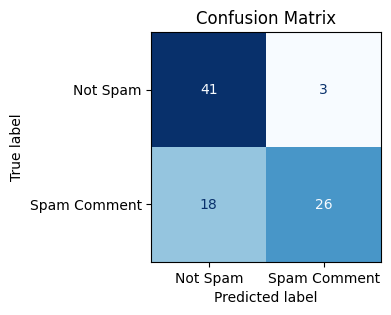

ROC-AUC: 0.9367252066115702


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Not Spam", "Spam Comment"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Spam", "Spam Comment"])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC-AUC (binarize labels)
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
# predict_proba for positive class if available
if hasattr(model.named_steps["clf"], "predict_proba"):
    y_scores = model.predict_proba(X_test)[:, 1]
else:
    # fallback: decision_function or dummy scores
    if hasattr(model.named_steps["clf"], "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        y_scores = (model.predict(X_test) == lb.classes_[1]).astype(int)

try:
    auc = roc_auc_score(y_test_bin, y_scores)
    print("ROC-AUC:", auc)
except Exception as e:
    print("ROC-AUC hesaplanamadı:", e)
